In [1]:
%load_ext autoreload
%autoreload 2

import pickle
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import corner
import matplotlib.pyplot as plt
import numpy as np
import corner, sys
import emcee
import getdist
from getdist import plots, MCSamples
%matplotlib inline
import matplotlib.pyplot as plt
sys.path.append('../../modules/')
import train_sbi_jax
import numpy as np
# ── 1. Load & prepare data ────────────────────────────────────────────────────

with open('../../capish_sbi_data/config_sbi_DESlike6_corrected_standard_prior_6_params/simulations.pkl', 'rb') as f:
    data = pickle.load(f)

counts_in_bins = data['x'][0]   # (6000, 4, 5)
masses_in_bins = data['x'][1]   # (6000, 4, 5)
theta_raw      = data['theta']  # (6000, 6)

counts_flat = counts_in_bins.reshape(len(counts_in_bins), -1).astype(np.float32)
masses_flat = masses_in_bins.reshape(len(masses_in_bins), -1).astype(np.float32)
x_raw     = np.concatenate([counts_flat, counts_flat * 10**masses_flat], axis=1)  # (6000, 40)
theta_raw = np.array(theta_raw, dtype=np.float32)

In [13]:
model, train_losses, val_losses, normalisation_setup = train_sbi_jax.train_sbi(theta_raw, x_raw, N_STEPS = 3000, normalize=True)

x shape     : (60000, 40)
theta shape : (60000, 6)
Training …


/pbs/throng/lsst/users/cpayerne/capish/sbi_with_JAX/train_sbi_jax.py:252: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  model = MAFlow(subkey)


  step     0  train=8.6579  val=8.5855
  step   500  train=-5.3995  val=-5.3127
  step  1000  train=-5.7264  val=-6.4420
  step  1500  train=-7.3920  val=-7.7973
  step  2000  train=-8.2810  val=-8.5127
  step  2500  train=-9.1783  val=-9.1080
  step  2999  train=-9.4915  val=-9.4403
Training complete.


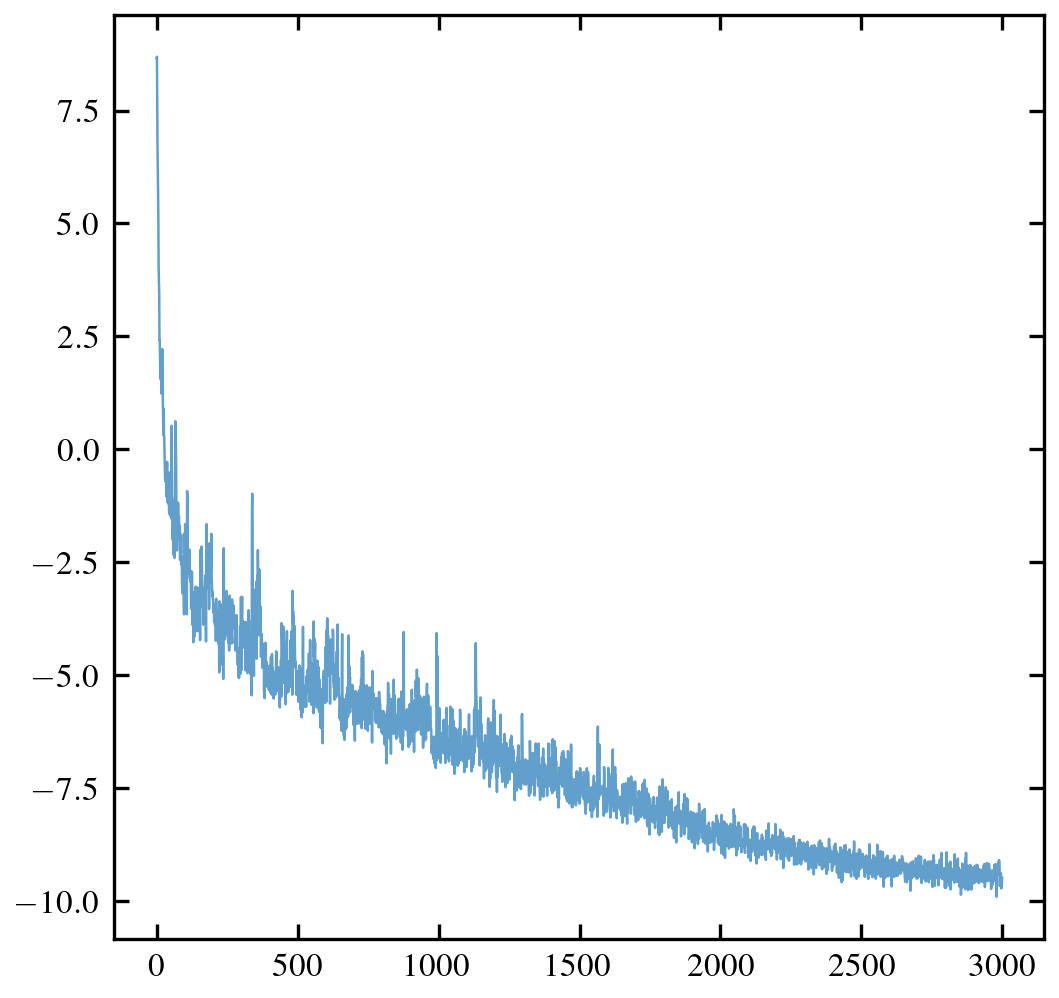

In [14]:
plt.figure(figsize=(4,4))
plt.plot(train_losses, lw=0.6, alpha=0.7, label="train")

In [15]:
with open('../../capish_sbi_data/config_sbi_DESlike6_corrected_narrow_prior_1_param/simulations.pkl', 'rb') as f:
    data = pickle.load(f)

counts_restricted_in_bins = data['x'][0]   # (6000, 4, 5)
masses_restricted_in_bins = data['x'][1]   # (6000, 4, 5)
theta_restricted_raw      = data['theta']  # (6000, 6)
counts_restricted_flat = counts_restricted_in_bins.reshape(len(counts_restricted_in_bins), -1).astype(np.float32)
masses_restricted_flat = masses_restricted_in_bins.reshape(len(masses_restricted_in_bins), -1).astype(np.float32)
x_restricted_raw     = np.concatenate([counts_restricted_flat, counts_restricted_flat * 10**masses_restricted_flat], axis=1)  # (6000, 40)theta_restricted_raw = np.array(theta_restricted_raw, dtype=np.float32)

In [16]:
normalize = True
if normalize:
    x_mean_log1p = normalisation_setup['x_mean_log1p']
    x_std_log1p = normalisation_setup['x_std_log1p'] 
    theta_mean = normalisation_setup['theta_mean']
    theta_std = normalisation_setup['theta_std']
    x_obs_n = np.mean(train_sbi_jax.preprocess_x(x_restricted_raw, x_mean_log1p, x_std_log1p), axis=0)
else: 
    x_obs_n = np.mean(x_restricted_raw, axis=0)
key = jax.random.PRNGKey(4)
key, subkey = jax.random.split(key)
flow_samples_n = model.sample(subkey, x_obs_n, 100000) 
if normalize:# normalised theta
    flow_samples   = train_sbi_jax.unnorm_theta(np.array(flow_samples_n), theta_mean, theta_std) 
else: flow_samples = flow_samples_n

In [17]:
names = ['1','2','3','4','5','6']
labels = [r'\Omega_m', r'\sigma_8', r'\mu^\lambda_0', r'\mu^\lambda_m',r'\mu^\lambda_z',r'\sigma_{\ln\lambda, {\rm int}}']
settings={'mult_bias_correction_order':0,'smooth_scale_2D':4, 'smooth_scale_1D':4, 'boundary_correction_order':0}

count_Nm_jax = MCSamples(samples=flow_samples,names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'count+Nm (JAX)')

Removed no burn in


In [18]:
n_cut=490000
path = '../../capish_sbi_data/config_sbi_DESlike6_corrected_standard_prior_6_params/samples_of_{}_posterior_with_data_flagship_like_sim.pkl'

t = np.load(path.format('count_Nm'), allow_pickle = True)
count_Nm_pysbi = MCSamples(samples=t[n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label=r'count+Nm (Python sbi)')

Removed no burn in


In [19]:
params_fid=[0.319,0.813,3.5,1.72,0,0.2]
minimum = [0.2, 0.6, 3.0, 1.3, -0.7, 0.1]
maximum = [0.45, 0.95, 4.0, 2.1, 0.7, 0.5]
print(minimum)

print(maximum)
range_ = {str(i+1): [minimum[i], maximum[i]] for i in range(len(params_fid))}
params_fid=[0.319,0.813,3.5,1.72,0,0.2]
markers={f'{i+1}':params_fid[i] for i in range(len(params_fid))}

[0.2, 0.6, 3.0, 1.3, -0.7, 0.1]
[0.45, 0.95, 4.0, 2.1, 0.7, 0.5]


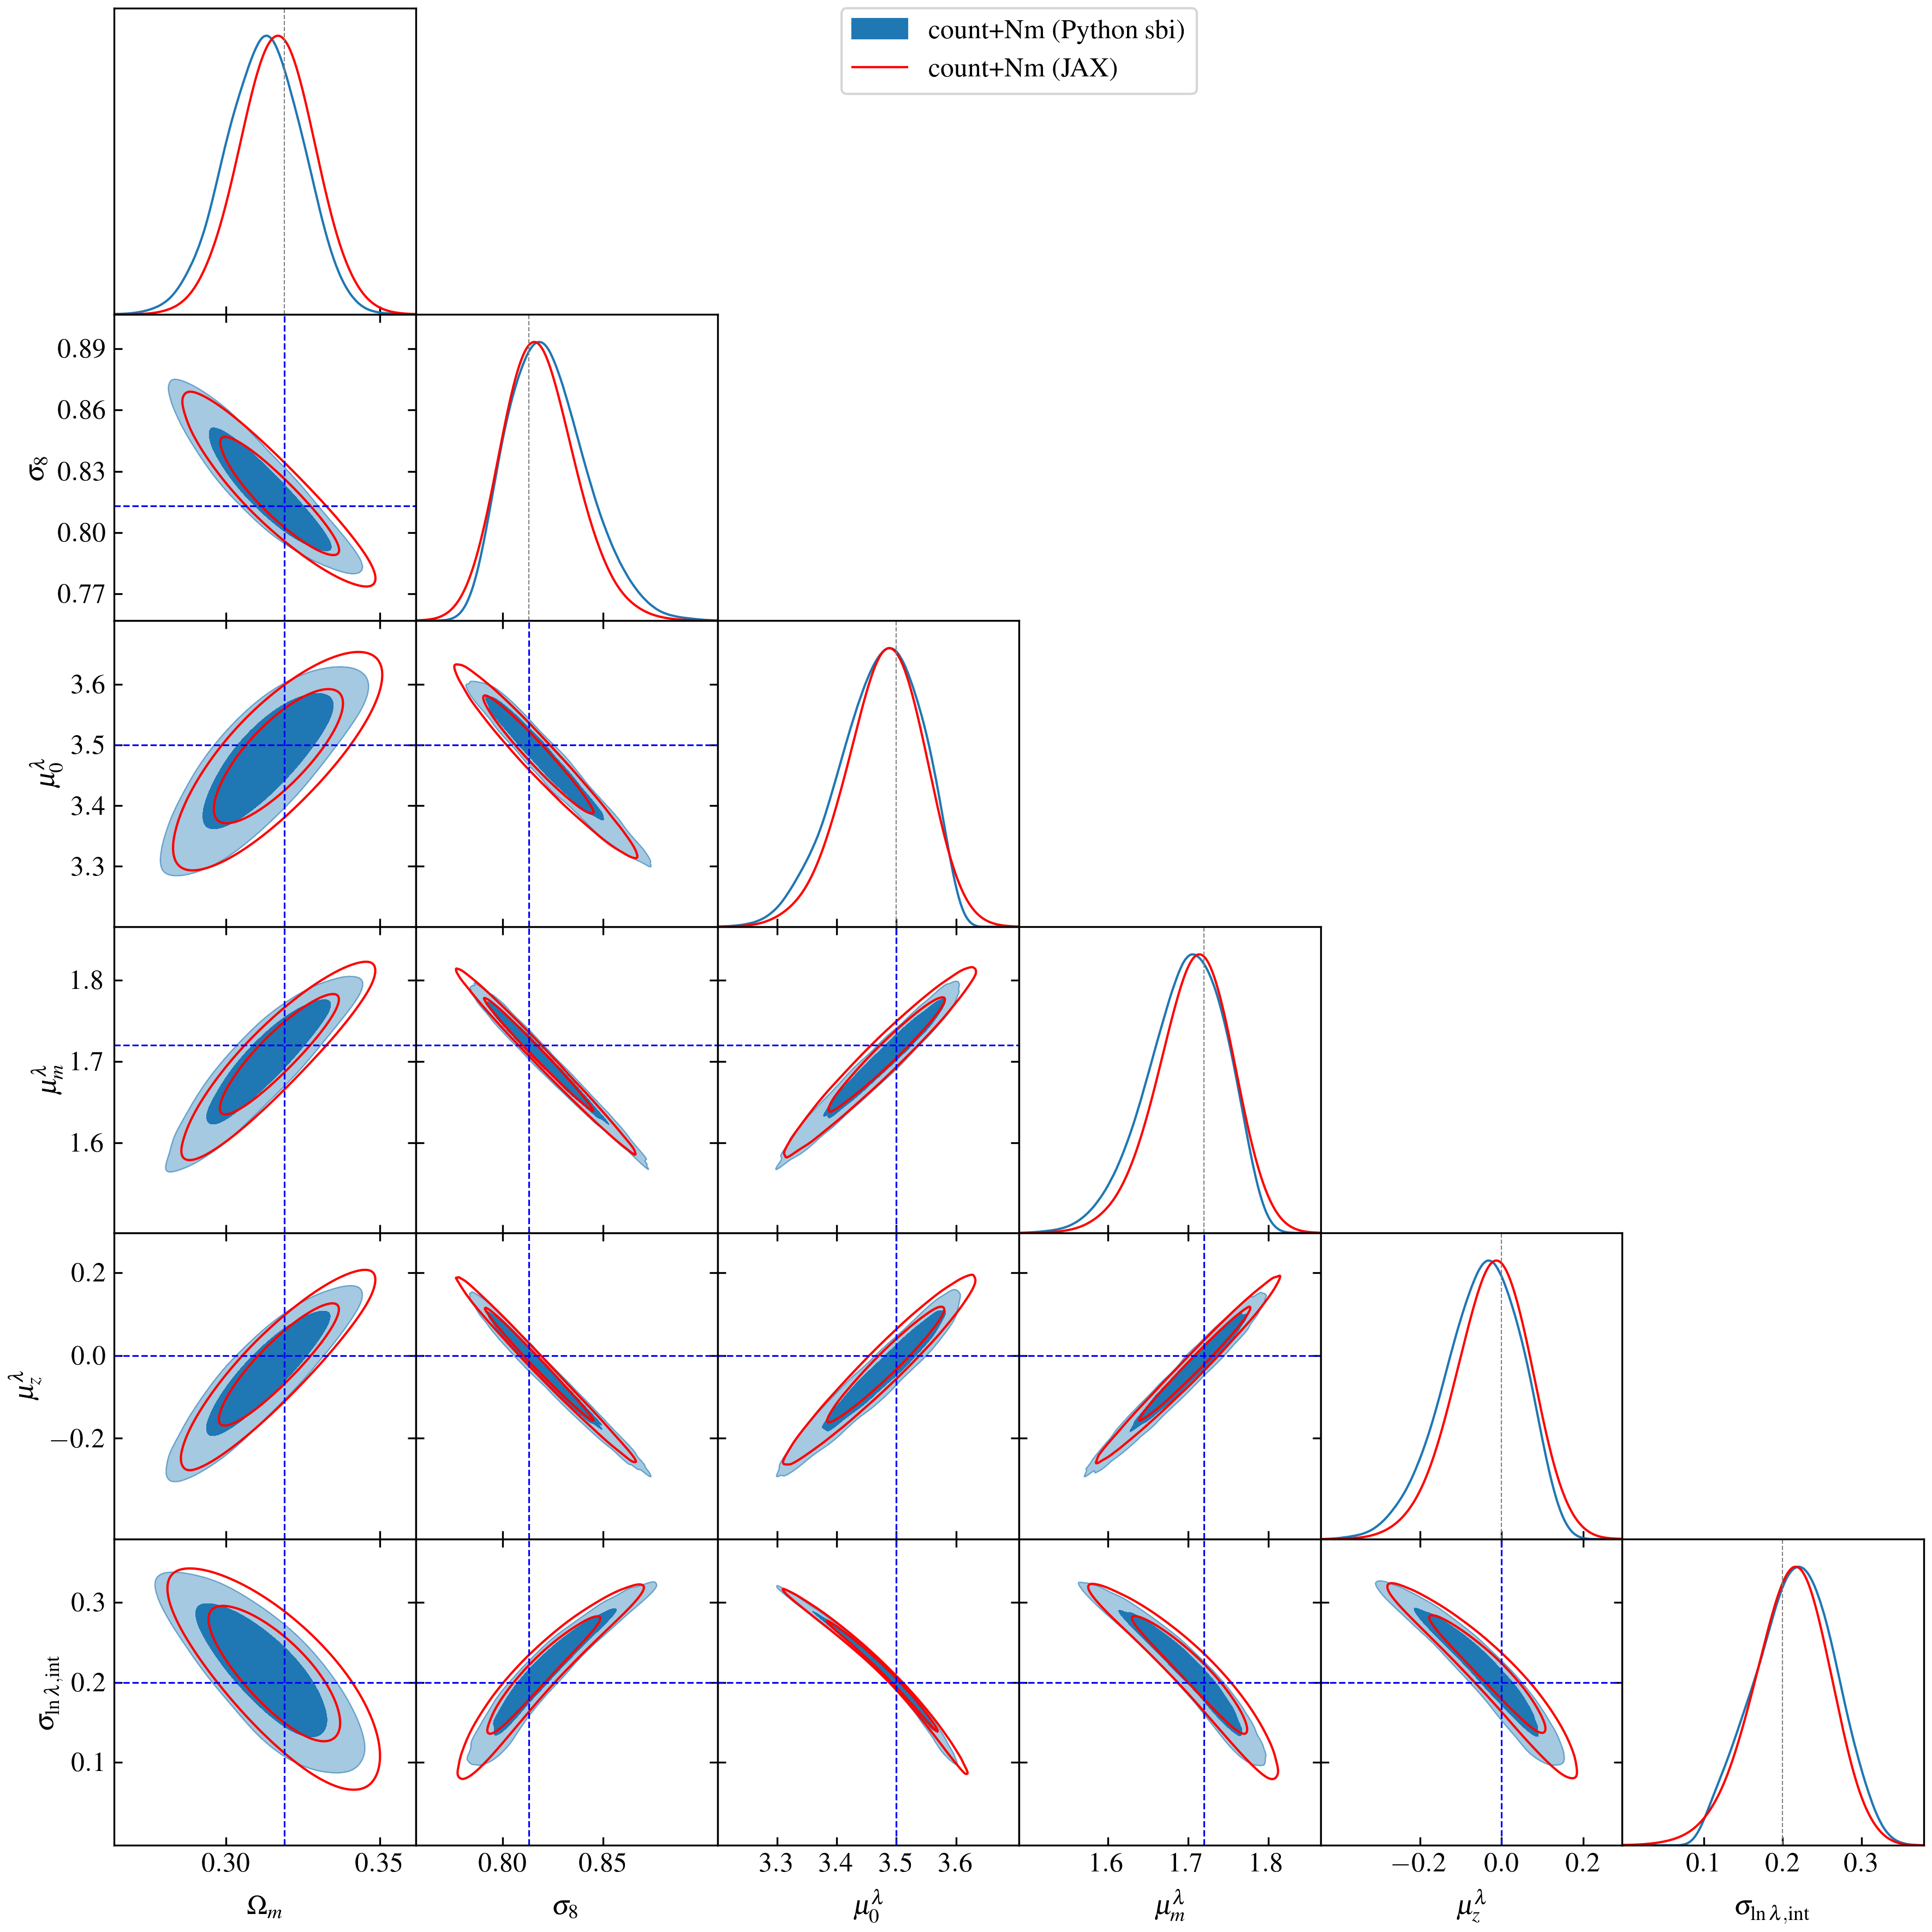

In [20]:
#plt.switch_backend("Qt5Agg")
params = {
    "font.family": "serif",
    "font.serif": ["Times", "Times New Roman", "DejaVu Serif"],
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "text.usetex": True,
    "figure.figsize": [3.386, 3.386],
    "figure.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
}
plt.rcParams.update(params)

g = plots.get_subplot_plotter(subplot_size=2)
g.settings.lab_fontsize = 15
g.settings.axes_fontsize = 15
g.settings.legend_fontsize = 15
marker_args = {'lw':0.75, 'markersize':0.75, 'ls':'--','color':'b'}
#range_ = {'1':[0.2, 0.5], '2':[0.6,0.9], '3':[2.5,4.5], '4':[1, 2.5],'5':[-1,1], '6':[0.1, 0.5], }
g.triangle_plot([count_Nm_pysbi, count_Nm_jax],
                #[N_Nm_power_law_log10Mwl_no_scatter],
                filled=[True, False, True,False, False, False], 
                contour_colors = ['C0', 'r', 'g','b', 'r', 'g',  ], 
                contour_ls=['-','-','-','--','--','--',],
                contour_lws=[1,1,1.5],
                #shaded=[False, False, True],
                legend_fontsize = 9,
                params=['1','2','3', '4', '5','6'],
                markers=markers,
                #param_limits = range_,
                fine_bins = 5,  
                marker_args = marker_args)
plt.savefig(f'../figures_for_paper/jax_vs_sbi.png', dpi = 300)